Dati estratti e salvati con successo per lo Step 2.


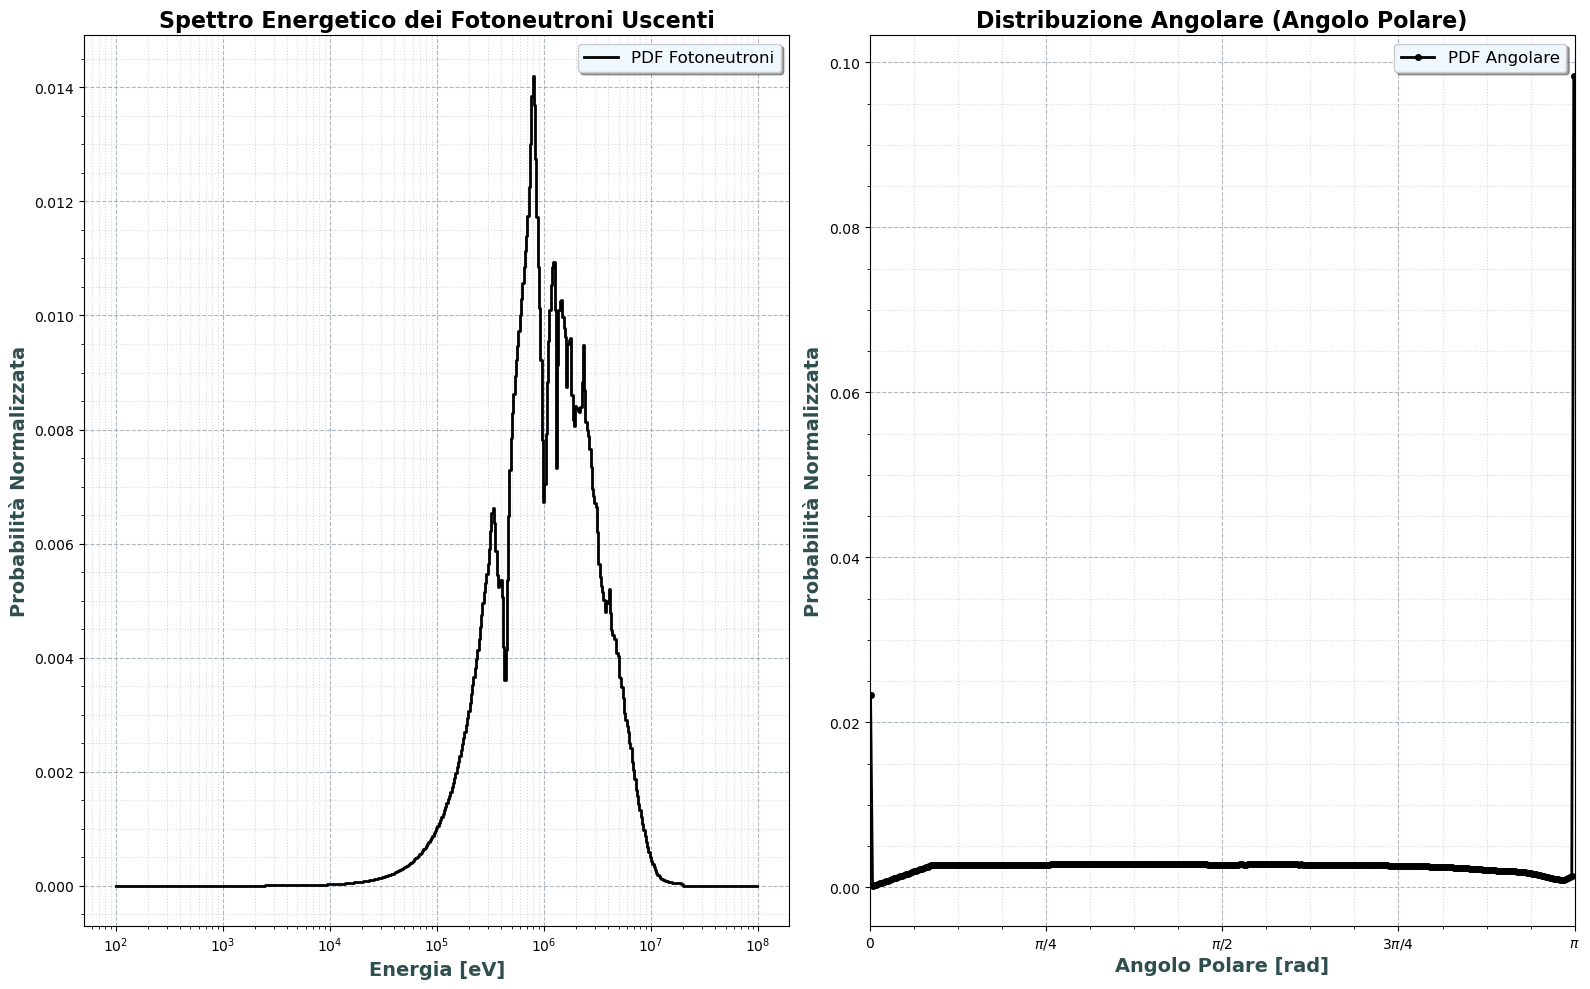

In [2]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

energy_bins = np.logspace(2, 8, 500)
polar_bins = np.linspace(0, np.pi, 360)

# Trova l'ultimo statepoint generato
sp_files = glob.glob('statepoint_*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato. La simulazione è fallita.")
latest_sp = max(sp_files, key=os.path.getctime)

# Caricamento risultati
with openmc.StatePoint(latest_sp) as sp:
    t_e = sp.get_tally(name='spettro_energia_neutroni')
    flux_e = t_e.mean.flatten()
    
    t_a = sp.get_tally(name='spettro_angolare_neutroni')
    flux_a = t_a.mean.flatten()

# Calcolo dei centri dei bin
energy_midpoints = 0.5 * (energy_bins[:-1] + energy_bins[1:])
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# Normalizzazione a PDF (Probability Density Function) per l'uso come sorgente
# Si evita la divisione per zero se il flusso è nullo
sum_e = np.sum(flux_e)
sum_a = np.sum(flux_a)

pdf_e = flux_e / sum_e if sum_e > 0 else flux_e
pdf_a = flux_a / sum_a if sum_a > 0 else flux_a

# Salvataggio su file di testo
np.savetxt("photoneutrons_energy.txt", np.column_stack((energy_midpoints, pdf_e)), 
           header="Energy_eV PDF", comments="")
np.savetxt("photoneutrons_polar.txt", np.column_stack((polar_midpoints, pdf_a)), 
           header="Polar_Angle_rad PDF", comments="")

print("Dati estratti e salvati con successo per lo Step 2.")

# =====================================================================
# 4. PLOTTING DEI RISULTATI
# =====================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# --- Plot Energetico ---
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutroni')
ax1.set_xscale('log')
ax1.set_title("Spettro Energetico dei Fotoneutroni Uscenti", fontsize=16, fontweight='bold')
ax1.set_xlabel("Energia [eV]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- Plot Angolare ---
ax2.plot(polar_midpoints, pdf_a, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare')
ax2.set_title("Distribuzione Angolare (Angolo Polare)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Angolo Polare [rad]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel("Probabilità Normalizzata", fontsize=14, fontweight='bold', color='#2F4F4F')

# Estetica asse angolare
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])

ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()